In [1]:
print("Hello from template!")

Hello from template!


In [2]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import cfg
from src.utils import set_seed

%load_ext autoreload
%autoreload 2
gseed = cfg.general.seed
set_seed(gseed)
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [3]:
df_train.loc[df_train["LotFrontage"].isna(), ["LotShape"]].value_counts()

LotShape
IR1         167
Reg          74
IR2          15
IR3           3
Name: count, dtype: int64

In [4]:
df_train.loc[df_train["Electrical"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [5]:
# информативнее смотреть по всем данным
df_all_data = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

df_all_data = df_all_data.drop(columns=["SalePrice"])
df_all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [6]:
df_all_data["GarageType"].value_counts()

GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

In [7]:
df_test.loc[332, "BsmtExposure"]

'No'

In [8]:
garage_columns = [
    "GarageType",
    "GarageFinish",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "GarageQual",
    "GarageCond",
]

garage_rows = df_all_data.loc[
    (df_all_data[garage_columns].isna().any(axis=1)),
    # & (~df_all_data[garage_columns].isna().all(axis=1)),
    garage_columns,
]

print(len(garage_rows) / df_all_data.shape[0])
print(garage_rows.index.tolist())
garage_rows

0.05447070914696814
[39, 48, 78, 88, 89, 99, 108, 125, 127, 140, 148, 155, 163, 165, 198, 210, 241, 250, 287, 291, 307, 375, 386, 393, 431, 434, 441, 464, 495, 520, 528, 533, 535, 562, 582, 613, 614, 620, 635, 636, 638, 649, 705, 710, 738, 750, 784, 826, 843, 921, 942, 954, 960, 968, 970, 976, 1009, 1011, 1030, 1038, 1096, 1123, 1131, 1137, 1143, 1173, 1179, 1218, 1219, 1234, 1257, 1283, 1323, 1325, 1326, 1337, 1349, 1407, 1449, 1450, 1453, 1513, 1531, 1539, 1552, 1556, 1558, 1560, 1590, 1593, 1594, 1614, 1615, 1717, 1721, 1787, 1808, 1810, 1811, 1819, 1822, 1831, 1834, 1836, 1839, 1847, 1893, 2010, 2081, 2090, 2093, 2096, 2099, 2104, 2126, 2135, 2151, 2153, 2189, 2190, 2191, 2192, 2193, 2212, 2238, 2246, 2353, 2354, 2398, 2399, 2422, 2426, 2552, 2553, 2557, 2575, 2576, 2579, 2603, 2609, 2691, 2693, 2708, 2767, 2771, 2789, 2791, 2799, 2859, 2862, 2870, 2888, 2891, 2892, 2893, 2909, 2913, 2914, 2917]


,GarageType,GarageFinish,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond
39,NaN,NaN,NaN,0.0,0.0,NaN,NaN
48,NaN,NaN,NaN,0.0,0.0,NaN,NaN
78,NaN,NaN,NaN,0.0,0.0,NaN,NaN
88,NaN,NaN,NaN,0.0,0.0,NaN,NaN
89,NaN,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...
2893,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2909,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2913,NaN,NaN,NaN,0.0,0.0,NaN,NaN
2914,NaN,NaN,NaN,0.0,0.0,NaN,NaN


In [9]:
df_all_data.loc[[2126, 2576], garage_columns]

,GarageType,GarageFinish,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond
2126,Detchd,NaN,NaN,1.0,360.0,NaN,NaN
2576,Detchd,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
basement_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
]

basement_rows = df_all_data.loc[
    (df_all_data[basement_cols].isna().any(axis=1))
    & (~df_all_data[basement_cols].isna().all(axis=1)),
    basement_cols,
]

print(len(basement_rows) / df_all_data.shape[0])
print(basement_rows.index.tolist())
basement_rows

0.029804727646454265
[17, 39, 90, 102, 156, 182, 259, 332, 342, 362, 371, 392, 520, 532, 533, 553, 646, 705, 736, 749, 778, 868, 894, 897, 948, 984, 1000, 1011, 1035, 1045, 1048, 1049, 1090, 1179, 1216, 1218, 1232, 1321, 1412, 1487, 1585, 1593, 1729, 1778, 1814, 1847, 1848, 1856, 1857, 1858, 1860, 1915, 2040, 2050, 2066, 2068, 2122, 2185, 2188, 2189, 2190, 2193, 2216, 2217, 2218, 2224, 2348, 2387, 2435, 2452, 2453, 2490, 2498, 2524, 2547, 2552, 2564, 2578, 2599, 2702, 2763, 2766, 2803, 2804, 2824, 2891, 2904]


,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
17,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
39,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
90,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
102,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
156,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2803,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2804,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2824,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2891,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
basement_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
]

basement_rows = df_all_data.loc[
    [332, 948, 1487, 2040, 2185, 2217, 2218, 2348, 2524], basement_cols
]

print(len(basement_rows) / df_all_data.shape[0])
basement_rows

0.003083247687564234


,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
332,Gd,TA,No,GLQ,NaN,1124.0,479.0,1603.0,3206.0,1.0,0.0
948,Gd,TA,NaN,Unf,Unf,0.0,0.0,936.0,936.0,0.0,0.0
1487,Gd,TA,NaN,Unf,Unf,0.0,0.0,1595.0,1595.0,0.0,0.0
2040,Gd,NaN,Mn,GLQ,Rec,1044.0,382.0,0.0,1426.0,1.0,0.0
2185,TA,NaN,No,BLQ,Unf,1033.0,0.0,94.0,1127.0,0.0,1.0
2217,NaN,Fa,No,Unf,Unf,0.0,0.0,173.0,173.0,0.0,0.0
2218,NaN,TA,No,Unf,Unf,0.0,0.0,356.0,356.0,0.0,0.0
2348,Gd,TA,NaN,Unf,Unf,0.0,0.0,725.0,725.0,0.0,0.0
2524,TA,NaN,Av,ALQ,Unf,755.0,0.0,240.0,995.0,0.0,0.0


In [12]:
# PoolQC          0.995205
# MiscFeature     0.963014
# Alley           0.937671
# Fence           0.807534
# MasVnrType      0.597260
# FireplaceQu     0.472603
# LotFrontage     0.177397
# GarageQual      0.055479
# GarageFinish    0.055479
# GarageType      0.055479
# GarageYrBlt     0.055479
# GarageCond      0.055479
# BsmtFinType2    0.026027
# BsmtExposure    0.026027
# BsmtCond        0.025342
# BsmtQual        0.025342
# BsmtFinType1    0.025342
# MasVnrArea      0.005479
# Electrical      0.000685

In [13]:
df_train.loc[df_train["MasVnrType"].isna(), ["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
...,...,...
1454,NaN,0.0
1455,NaN,0.0
1457,NaN,0.0
1458,NaN,0.0


In [14]:
# не все nan имеют 0
(df_train.loc[df_train["MasVnrType"].isna(), "MasVnrArea"] == 0).all()


np.False_

In [15]:
mask = df_train.loc[df_train["MasVnrType"].isna(), "MasVnrArea"] == 0
part = df_train.loc[df_train["MasVnrType"].isna(), ["MasVnrType", "MasVnrArea"]]
part[~mask]


,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
624,NaN,288.0
650,NaN,NaN
773,NaN,1.0
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1230,NaN,1.0
1243,NaN,NaN


In [16]:
df_all_data.loc[df_all_data["MSZoning"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1915,1916,30,NaN,109.0,21780,Grvl,NaN,Reg,Lvl,NaN,...,0,0,NaN,NaN,NaN,0,3,2009,ConLD,Normal
2216,2217,20,NaN,80.0,14584,Pave,NaN,Reg,Low,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Abnorml
2250,2251,70,NaN,NaN,56600,Pave,NaN,IR1,Low,AllPub,...,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal
2904,2905,20,NaN,125.0,31250,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal


In [17]:
df_all_data.loc[df_all_data["Utilities"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1915,1916,30,NaN,109.0,21780,Grvl,NaN,Reg,Lvl,NaN,...,0,0,NaN,NaN,NaN,0,3,2009,ConLD,Normal
1945,1946,20,RL,NaN,31220,Pave,NaN,IR1,Bnk,NaN,...,0,0,NaN,NaN,Shed,750,5,2008,WD,Normal


In [18]:
df_all_data.loc[df_all_data["Functional"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2216,2217,20,NaN,80.0,14584,Pave,NaN,Reg,Low,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Abnorml
2473,2474,50,RM,60.0,10320,Pave,Grvl,Reg,Lvl,AllPub,...,84,0,NaN,NaN,NaN,0,9,2007,COD,Abnorml


In [19]:
df_all_data.loc[df_all_data["Exterior1st"].isna()].to_dict()

{'Id': {2151: 2152},
 'MSSubClass': {2151: 30},
 'MSZoning': {2151: 'RL'},
 'LotFrontage': {2151: 85.0},
 'LotArea': {2151: 19550},
 'Street': {2151: 'Pave'},
 'Alley': {2151: nan},
 'LotShape': {2151: 'Reg'},
 'LandContour': {2151: 'Lvl'},
 'Utilities': {2151: 'AllPub'},
 'LotConfig': {2151: 'Inside'},
 'LandSlope': {2151: 'Gtl'},
 'Neighborhood': {2151: 'Edwards'},
 'Condition1': {2151: 'Norm'},
 'Condition2': {2151: 'Norm'},
 'BldgType': {2151: '1Fam'},
 'HouseStyle': {2151: '1Story'},
 'OverallQual': {2151: 5},
 'OverallCond': {2151: 7},
 'YearBuilt': {2151: 1940},
 'YearRemodAdd': {2151: 2007},
 'RoofStyle': {2151: 'Flat'},
 'RoofMatl': {2151: 'Tar&Grv'},
 'Exterior1st': {2151: nan},
 'Exterior2nd': {2151: nan},
 'MasVnrType': {2151: nan},
 'MasVnrArea': {2151: 0.0},
 'ExterQual': {2151: 'TA'},
 'ExterCond': {2151: 'TA'},
 'Foundation': {2151: 'PConc'},
 'BsmtQual': {2151: 'TA'},
 'BsmtCond': {2151: 'TA'},
 'BsmtExposure': {2151: 'Gd'},
 'BsmtFinType1': {2151: 'ALQ'},
 'BsmtFinSF1

In [20]:
df_all_data.loc[df_all_data["SaleType"].isna()].to_dict()

{'Id': {2489: 2490},
 'MSSubClass': {2489: 20},
 'MSZoning': {2489: 'RL'},
 'LotFrontage': {2489: 85.0},
 'LotArea': {2489: 13770},
 'Street': {2489: 'Pave'},
 'Alley': {2489: nan},
 'LotShape': {2489: 'Reg'},
 'LandContour': {2489: 'Lvl'},
 'Utilities': {2489: 'AllPub'},
 'LotConfig': {2489: 'Corner'},
 'LandSlope': {2489: 'Gtl'},
 'Neighborhood': {2489: 'Sawyer'},
 'Condition1': {2489: 'Feedr'},
 'Condition2': {2489: 'Norm'},
 'BldgType': {2489: '1Fam'},
 'HouseStyle': {2489: '1Story'},
 'OverallQual': {2489: 5},
 'OverallCond': {2489: 6},
 'YearBuilt': {2489: 1958},
 'YearRemodAdd': {2489: 1998},
 'RoofStyle': {2489: 'Gable'},
 'RoofMatl': {2489: 'CompShg'},
 'Exterior1st': {2489: 'Plywood'},
 'Exterior2nd': {2489: 'Plywood'},
 'MasVnrType': {2489: 'BrkFace'},
 'MasVnrArea': {2489: 340.0},
 'ExterQual': {2489: 'TA'},
 'ExterCond': {2489: 'TA'},
 'Foundation': {2489: 'CBlock'},
 'BsmtQual': {2489: 'TA'},
 'BsmtCond': {2489: 'TA'},
 'BsmtExposure': {2489: 'Mn'},
 'BsmtFinType1': {2489

In [21]:
df_all_data.loc[df_all_data["KitchenQual"].isna()].to_dict()

{'Id': {1555: 1556},
 'MSSubClass': {1555: 50},
 'MSZoning': {1555: 'RL'},
 'LotFrontage': {1555: 72.0},
 'LotArea': {1555: 10632},
 'Street': {1555: 'Pave'},
 'Alley': {1555: nan},
 'LotShape': {1555: 'IR1'},
 'LandContour': {1555: 'Lvl'},
 'Utilities': {1555: 'AllPub'},
 'LotConfig': {1555: 'Inside'},
 'LandSlope': {1555: 'Gtl'},
 'Neighborhood': {1555: 'ClearCr'},
 'Condition1': {1555: 'Norm'},
 'Condition2': {1555: 'Norm'},
 'BldgType': {1555: '1Fam'},
 'HouseStyle': {1555: '1.5Fin'},
 'OverallQual': {1555: 5},
 'OverallCond': {1555: 3},
 'YearBuilt': {1555: 1917},
 'YearRemodAdd': {1555: 1950},
 'RoofStyle': {1555: 'Gable'},
 'RoofMatl': {1555: 'CompShg'},
 'Exterior1st': {1555: 'Wd Sdng'},
 'Exterior2nd': {1555: 'Wd Sdng'},
 'MasVnrType': {1555: nan},
 'MasVnrArea': {1555: 0.0},
 'ExterQual': {1555: 'TA'},
 'ExterCond': {1555: 'TA'},
 'Foundation': {1555: 'BrkTil'},
 'BsmtQual': {1555: 'Gd'},
 'BsmtCond': {1555: 'Fa'},
 'BsmtExposure': {1555: 'No'},
 'BsmtFinType1': {1555: 'Unf'}

In [ ]:
df_train["YearRemodAdd"].argmin()

np.int64(8)

array([[<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>],
       [<Axes: title={'center': 'GarageYrBlt'}>,
        <Axes: title={'center': 'YrSold'}>]], dtype=object)

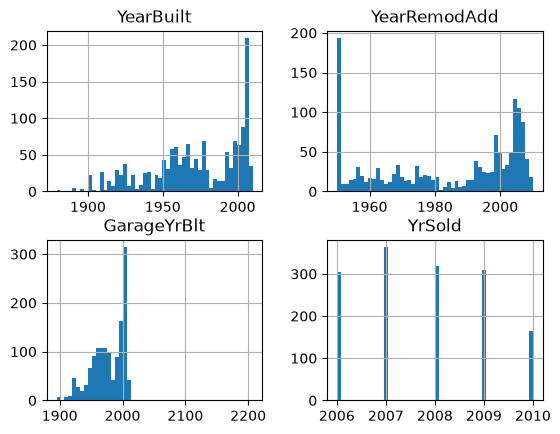

In [ ]:
df_test.loc[:, ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]].hist(bins=50)

In [ ]:
df_all_data[["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]].max()

YearBuilt       2010.0
YearRemodAdd    2010.0
GarageYrBlt     2207.0
YrSold          2010.0
dtype: float64

In [ ]:
df_all_data[df_all_data["GarageYrBlt"] > 2010]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2592,2593,20,RL,68.0,8298,Pave,NaN,IR1,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,9,2007,New,Partial


oe - ordinal encoder
ohe - one hot encoder

Значения Nan
* PoolQC - нет бассейна - пропуск-категория + oe
* MiscFeature - нет особенности - пропуск-категория + ohe
* Alley - нет дорожки - пропуск-категория + ohe
* Fence - нет забора - пропуск-категория + ohe
* MasVnrType - нет обшивки - пропуск-категория + ohe
    
    MasVnrArea - нет обшивки - заполнить 0
* FireplaceQu - нет камина - пропуск-категория + oe
* LotFrontage - преимущественно у необычной LotShape - чем-то заполнить
* GarageQual - пропуск-категория + oe

    GarageFinish - пропуск-категория + oe

    GarageType - пропуск-категория + ohe

    GarageCond- пропуск-категория + oe

    GarageYrBlt - лучше создать отдельный флаг на наличие гаражи и заполнить годом постройки дома

    GarageCars - заполнить нулем

    GarageArea- заполнить нулем
    
    Пропуски в этих колонках из-за отсутствия гаража, [2126, 2576] - баги

* BsmtQual - пропуск-категория - oe

    BsmtCond - пропуск-категория - oe

    BsmtExposure - пропуск-категория - oe

    BsmtFinType1 - пропуск-категория - oe

    BsmtFinType2 - пропуск-категория - oe

    BsmtFinSF1 - заполнить нулем

    BsmtFinSF2 - заполнить нулем

    BsmtUnfSF - заполнить нулем

    TotalBsmtSF - заполнить нулем

    BsmtFullBath - заполнить нулем

    BsmtHalfBath - заполнить нулем

    В большинстве своем пропуск - нет подвала, [332, 948, 1487, 2040, 2185, 2217, 2218, 2348, 2524] - баги

* Electrical - обычный пропуск - чем-то заполнить + ohe
* MSZoning - обычный пропуск - чем-то заполнить  + ohe
* Utilities - обычный пропуск - чем-то заполнить + oe
* Functional - обычный пропуск - чем-то заполнить + oe
* Exterior1st & Exterior2nd - обычный парный пропуск - чем-то заполнить + ohe
* SaleType - обычный пропуск - чем-то заполнить + ohe
* KitchenQual - обычный пропуск - чем-то заполнить + oe

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class MemoryOptimizer(BaseEstimator, TransformerMixin):
    def __init__(self, float16_as32=True, optimize_categories=True, cat_threshold=None):
        self.float16_as32 = float16_as32
        self.optimize_categories = optimize_categories
        self.cat_threshold = cat_threshold

    def fit(self, X, y=None):
        self._validate_input(X)

        self.categorical_cols_ = []
        self.numeric_downcast_rules_ = {}

        for col in X.columns:
            col_type = X[col].dtype

            if self.optimize_categories and (
                col_type == "object" or col_type.name == "string"
            ):
                if self.cat_threshold is None or X[col].nunique() <= self.cat_threshold:
                    self.categorical_cols_.append(col)
                continue

            if col_type.name == "category":
                continue

            if "int" in str(col_type):
                downcasted = pd.to_numeric(X[col], downcast="integer")
                self.numeric_downcast_rules_[col] = downcasted.dtype

            elif "float" in str(col_type):
                downcasted = pd.to_numeric(X[col], downcast="float")
                if self.float16_as32 and downcasted.dtype == np.float16:
                    self.numeric_downcast_rules_[col] = np.dtype(np.float32)
                else:
                    self.numeric_downcast_rules_[col] = downcasted.dtype

        return self

    def transform(self, X):
        self._validate_input(X)
        self._check_is_fitted()

        X_out = X.copy()
        start_mem = X_out.memory_usage(deep=True).sum() / 1024**2

        if self.optimize_categories:
            for col in self.categorical_cols_:
                if col in X_out.columns:
                    X_out[col] = X_out[col].astype("category")

        for col, target_dtype in self.numeric_downcast_rules_.items():
            if col in X_out.columns:
                X_out[col] = X_out[col].astype(target_dtype)

        end_mem = X_out.memory_usage(deep=True).sum() / 1024**2
        percent_decrease = (
            100 * (start_mem - end_mem) / start_mem if start_mem > 0 else 0
        )
        print(
            f"Оптимизация памяти завершена: {start_mem:.2f} MB -> {end_mem:.2f} MB (-{percent_decrease:.1f}%)"
        )

        return X_out

    @staticmethod
    def _validate_input(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("X должен быть экземпляром pandas.DataFrame")

    def _check_is_fitted(self):
        if not hasattr(self, "categorical_cols_") or not hasattr(
            self, "numeric_downcast_rules_"
        ):
            raise RuntimeError("Трансформер не обучен. Сначала вызовите fit().")